In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student/student_clustering.csv


In [2]:
df = pd.read_csv("/kaggle/input/student/student_clustering.csv")
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [3]:
df.shape

(200, 2)

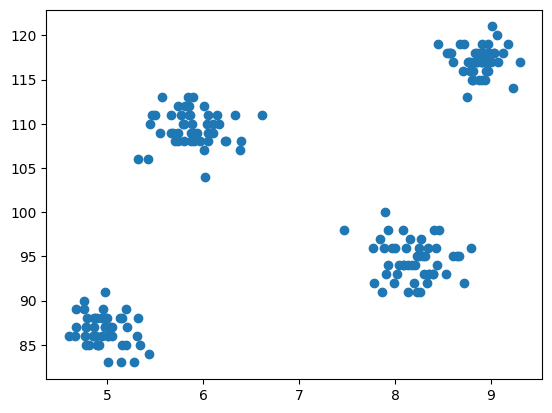

In [4]:
import matplotlib.pyplot as plt 
plt.scatter(df['cgpa'],df['iq'])

In [5]:
from sklearn.cluster import KMeans

In [6]:
#Elbow Method
wcss=[]

for i in range(1,11):
    km =KMeans(n_clusters = i)
    km.fit_predict(df)
    wcss.append(km.inertia_)

In [7]:
wcss

[29957.898288000004,
 4184.141270000001,
 2503.397581000001,
 681.9696600000003,
 523.7131894763967,
 398.4039118468833,
 317.85379321596054,
 240.75513461897907,
 214.09796174962617,
 217.28677429391644]

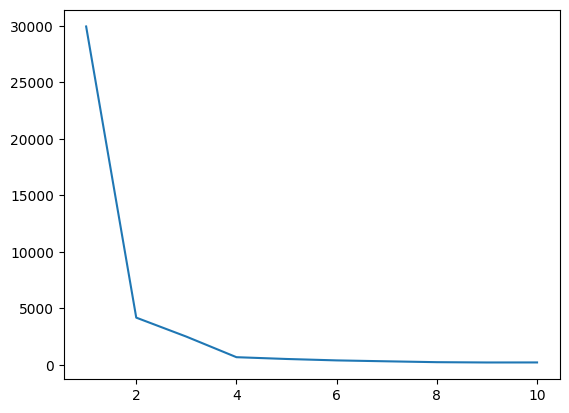

In [8]:
plt.plot(range(1,11),wcss)

In [9]:
X = df.iloc[:,:].values
km = KMeans(n_clusters = 4)
y_pred = km.fit_predict(X)

In [10]:
y_pred

array([3, 2, 0, 0, 2, 2, 0, 1, 2, 0, 3, 2, 0, 3, 2, 0, 2, 0, 2, 2, 0, 3,
       0, 3, 3, 0, 3, 1, 0, 2, 1, 2, 1, 2, 0, 0, 1, 2, 3, 2, 3, 0, 0, 3,
       1, 1, 0, 2, 1, 2, 3, 3, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0, 0, 1, 3, 1,
       0, 3, 2, 0, 2, 1, 0, 3, 2, 1, 2, 1, 3, 0, 0, 1, 2, 3, 1, 3, 1, 2,
       1, 2, 1, 1, 0, 3, 0, 0, 1, 0, 3, 1, 2, 3, 3, 1, 3, 3, 0, 3, 1, 1,
       0, 1, 2, 2, 0, 1, 0, 2, 1, 3, 3, 2, 0, 1, 0, 3, 0, 2, 3, 0, 0, 2,
       3, 3, 2, 1, 2, 3, 0, 0, 0, 3, 2, 3, 3, 1, 3, 1, 2, 3, 1, 3, 1, 1,
       3, 0, 2, 1, 2, 0, 3, 1, 2, 0, 1, 3, 2, 3, 3, 1, 1, 2, 1, 3, 3, 0,
       1, 2, 3, 1, 1, 2, 2, 2, 0, 3, 0, 0, 1, 2, 0, 0, 3, 3, 0, 3, 1, 2,
       2, 1], dtype=int32)

In [11]:
X[y_pred == 3,1] #[class,axis]

array([88., 86., 88., 86., 87., 88., 87., 84., 85., 86., 83., 86., 87.,
       85., 83., 88., 85., 88., 86., 91., 86., 88., 89., 86., 90., 87.,
       87., 85., 87., 83., 86., 87., 85., 87., 87., 88., 88., 85., 86.,
       86., 86., 85., 88., 88., 89., 88., 88., 89., 85., 89.])

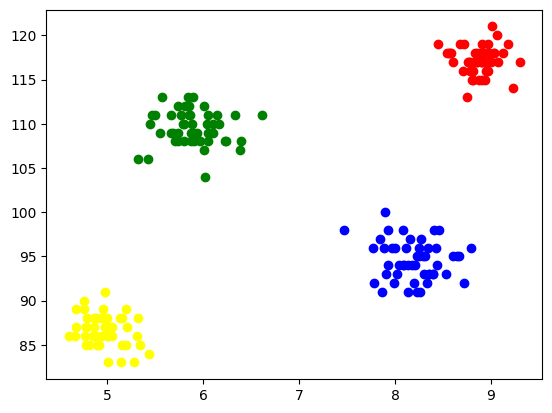

In [12]:
plt.scatter(X[y_pred == 0,0],X[y_pred == 0,1],color='blue')
plt.scatter(X[y_pred == 1,0],X[y_pred == 1,1],color='red')
plt.scatter(X[y_pred == 2,0],X[y_pred == 2,1],color='green')
plt.scatter(X[y_pred == 3,0],X[y_pred == 3,1],color='yellow')

on 3d

In [13]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [14]:
X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

In [15]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0],y = X[:,1],z = X[:,2])
fig.show()

In [16]:
wcss = []


for i in range(1,21) :
    km = KMeans(n_clusters = i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

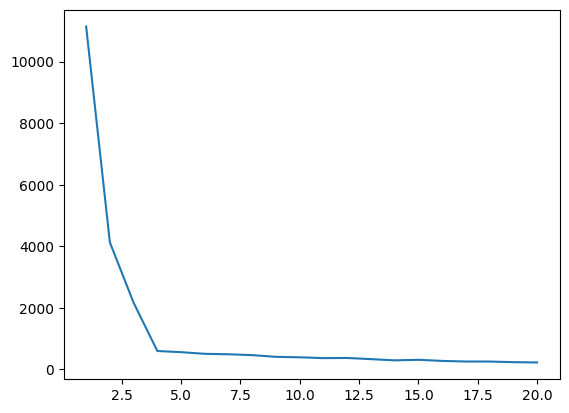

In [17]:
plt.plot(range(1,21),wcss)

In [18]:
km = KMeans(n_clusters = 4)
y_pred = km.fit_predict(X)

In [19]:
df = pd.DataFrame()

In [20]:
X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

In [21]:
df['col1']  = X[:,0]
df['col2']  = X[:,1]
df['col3']  = X[:,2]
df['label'] = y_pred

In [22]:
df

,col1,col2,col3,label
0,4.334245,3.325804,-4.174970,2
1,-3.322467,3.221711,-4.625342,0
2,-6.072969,-4.134592,2.698461,3
3,6.904659,6.111057,-4.340950,2
4,-2.608392,2.950156,-2.234665,0
...,...,...,...,...
195,4.712692,5.680070,-5.319802,2
196,-4.137450,6.458603,-3.351356,0
197,-5.208894,-4.413377,5.838983,3
198,2.619422,-2.779098,5.622849,1


In [23]:
fig = px.scatter_3d(df,x=df['col1'],y = df['col2'],z = df['col3'],color=df['label'])
fig.show()